**CUSTOMER SEGMENTATION ON ONLINE RETAIL DATSET**

**1. Project Overview**

Customer segmentation helps businesses identify groups of customers with similar purchasing behavior.
By understanding these segments, companies can design targeted marketing strategies, improve retention, and increase revenue.
In this project we use RFM analysis (Recency, Frequency, Monetary) combined with K-Means clustering to segment customers based on their purchasing patterns.

Objectives:
Understand customer purchasing behavior
Build RFM features
Apply clustering to identify customer groups
Generate insights for marketing strategies

**2. Import Libraries**

In [163]:
#import the required libraries
import numpy as np 
import pandas as pd 
import seaborn as sns  
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


**3. Load Dataset**

In [164]:
#loading of dataset
online_retail = pd.read_csv('online_retail.csv')
online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Understanding the dataset:
    Typical columns include
        InvoiceNo
        StockCode
        Description
        Quantity
        InvoiceDate
        UnitPrice
        CustomerID
        Country
    Each row represents a transaction made by a customer.

**4. Initial Data Exploration**

In [165]:
#size of the data
online_retail.shape

(541909, 8)

In [166]:
#checking the data types of columns
online_retail.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [167]:
#checking the description for numerical values
online_retail.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


**5. Data Cleaning**

We remove:
    Missing customer IDs ,
    Negative quantities (returns) ,
    Negative prices

In [168]:
#creating a copy of data to do analysis
clean_online_retail = online_retail.copy()
clean_online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [169]:
#checking null values
clean_online_retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [170]:
#deleting CustomerId where the values are NaN
clean_online_retail.dropna(subset = ['CustomerID'], inplace =True)
clean_online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


If we don't know who bought the item, we can't track customer behavior over time. Hence, I am deleting CustomerId with NaN values.

In [171]:
#filtering out returns and cancelled orders
clean_online_retail = clean_online_retail[clean_online_retail['Quantity'] > 0]

In this dataset, negative quantities represent cancelled orders or returns.

In [172]:
#filtering out errors
clean_online_retail = clean_online_retail[clean_online_retail['UnitPrice'] > 0]

Zero or negative prices usually represent bad data, gifts, or adjustments. Including these would skew average order value and total revenue.

**6. Feature Engineering**

In [173]:
#converting the Invoicedata column from string to a specialized datetime object
clean_online_retail['InvoiceDate'] = pd.to_datetime(clean_online_retail['InvoiceDate'])

We can't perform math on text. Converting to datetime allows us to extract the month, day, or hour, and calculate "Recency" (how many days since the last purchase).

In [174]:
#Derived feature
#creating a new column called TotalPrice 
clean_online_retail['TotalPrice'] = clean_online_retail['Quantity'] * clean_online_retail['UnitPrice']

The dataset provides the attributes of a sale, but not the final total. We need this column to calculate the Monetary value of your customers.

In [175]:
#cleaned data overview
clean_online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [176]:
#size of the data
clean_online_retail.shape

(397884, 9)

In [177]:
#checking the data types of columns
clean_online_retail.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
TotalPrice            float64
dtype: object

In [178]:
#checking the description for numerical values
clean_online_retail.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [179]:
#checking null values
clean_online_retail.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

**7. Exploratory Data Analysis**

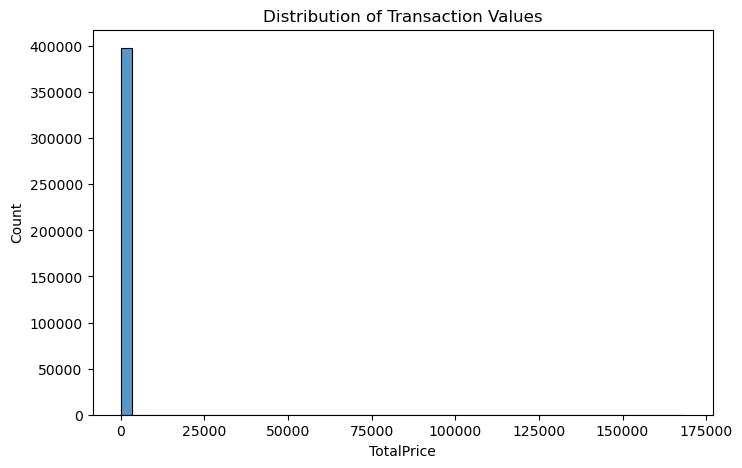

In [180]:
#Distribution of transaction value
plt.figure(figsize=(8,5))
sns.histplot(clean_online_retail['TotalPrice'], bins=50)
plt.title("Distribution of Transaction Values")
plt.show()

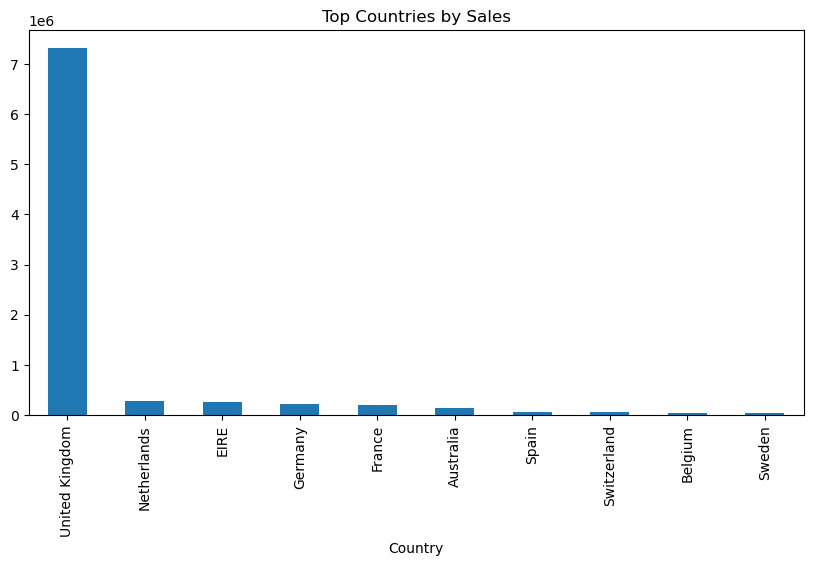

In [181]:
#Top countries by sale

country_sales = clean_online_retail.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_sales.head(10).plot(kind='bar')
plt.title("Top Countries by Sales")
plt.show()

**8. RFM Analysis:**

RFM stands for:

Recency (R):Days since the last purchase i.e; how recently a customer purchased

Frequency (F):Total number of unique purchase events or how often a customer purchased

Monetary (M):Total revenue generated from the customer or how much money a customer spends

We calculate these metrics for each customer.

In [182]:
#Defining the reference point for recency i.e.; Recency calculation
snapshot_date = clean_online_retail['InvoiceDate'].max() + pd.Timedelta(days=1)

It finds very last date in the dataset and adds one day to it.
This provides a fixed reference point so that every customer has a valid Recency value. 

In [183]:
#Grouping and calculating the 3 pillars - RFM
rfm_df = clean_online_retail.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days, # Recency
    'InvoiceNo': 'nunique', # Frequency
    'TotalPrice': 'sum' # Monetary
})

Recency: Difference between snapshot date and the latest purchase date
Frequency: Number of unique invoices (prevents double-counting items in one order)
Monetary: Sum of all transaction values
Using nunique is better than count because if a customer bought 10 items in a single order, count would say 10, but nunique correctly identifies it as 1 transaction.

In [184]:
#Renaming for clarity
rfm_df.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'Monetary'}, inplace=True)

It makes resulting data easy to read . It changes the technical column names InvoiceDate to Receny , InvoiceNo to Frequency and TotalPrice to Monetary 

In [185]:
#Checking the dataframe
rfm_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [186]:
# Define scoring functions for R, F, and M
def get_score(column, reverse=False):
    _, bins = pd.qcut(column, q=5, retbins=True, duplicates='drop')
    num_bins = len(bins) - 1
    labels = list(range(num_bins, 0, -1)) if reverse else list(range(1, num_bins + 1))
    return pd.qcut(column, q=5, labels=labels, duplicates='drop')
# Apply scores
rfm_df['R_score'] = get_score(rfm_df['Recency'], reverse=True)
rfm_df['F_score'] = get_score(rfm_df['Frequency'])
rfm_df['M_score'] = get_score(rfm_df['Monetary'])
# Concatenate scores to create a unique RFM Segment ID
rfm_df['RFM_segment'] = (rfm_df['R_score'].astype(str) +
                         rfm_df['F_score'].astype(str) +
                         rfm_df['M_score'].astype(str))
rfm_df.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_segment
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,4,5,545
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


1. def get_score(column, reverse=False):  
            For RFM, high isn't always good.
            For Recency, low is good.
            For Monetary, high is good.
            This function allows us to handle both cases with one block of code
   
2. _, bins = pd.qcut(column, q=5, retbins=True, duplicates='drop')
            q=5: Finds the quintiles (the 20th, 40th, 60th, and 80th percentiles).
            retbins = True: Returns actual boundary values of the bins.
            Underscore _ to ignore the first output .
            duplicates='drop': Many customers might have the same value . Drops overlapping boundaries to keep the code stable.

   
3. num_bins = len(bins) - 1
   labels = list(range(num_bins, 0, -1)) if reverse else list(range(1, num_bins + 1))
            len(bins) - 1: 6 boundary points, we have 5 bins for data.
            The List Logic: If reverse=True (Recency): It creates [5, 4, 3, 2, 1].
                            If reverse=False (Frequency/Monetary): It creates [1, 2, 3, 4, 5].

   
4. rfm_clean_online_retail['R_score'] = get_score(rfm_df['Recency'], reverse=True)
   rfm_clean_online_retail['F_score'] = get_score(rfm_df['Frequency'])
   rfm_clean_online_retail['M_score'] = get_score(rfm_df['Monetary'])
             Function three times and save the results as new columns.

   
5. String Concatenation (The Segment ID)
   rfm_clean_online_retail['RFM_segment'] = (rfm_clean_online_retail['R_score'].astype(str) + rfm_clean_online_retail['F_score'].astype(str) + 
   rfm_clean_online_retail['M_score'].astype(str))
            .astype(str): This creates a unique 3-digit tag for every customer.

**9 . RFM Distribution Analysis**

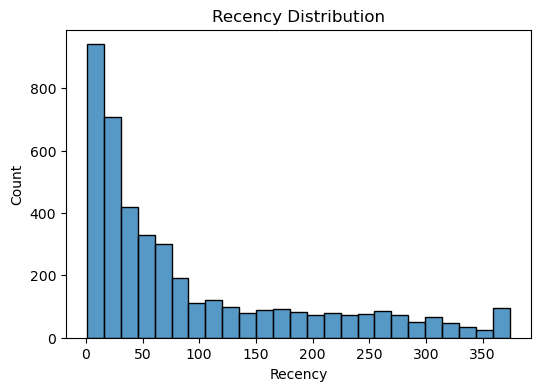

In [187]:
plt.figure(figsize=(6,4))
sns.histplot(rfm_df['Recency'])
plt.title("Recency Distribution")
plt.show()

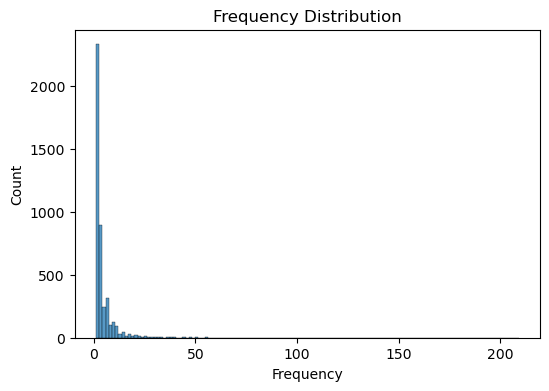

In [188]:
plt.figure(figsize=(6,4))
sns.histplot(rfm_df['Frequency'])
plt.title("Frequency Distribution")
plt.show()

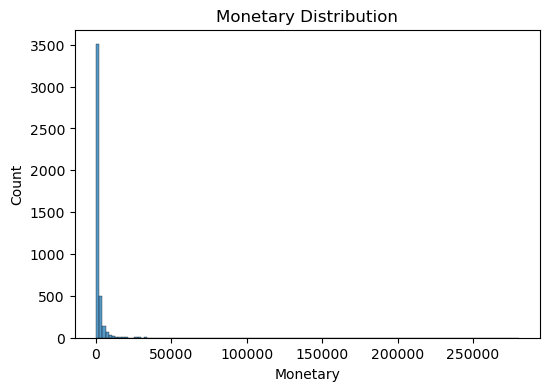

In [189]:
plt.figure(figsize=(6,4))
sns.histplot(rfm_df['Monetary'])
plt.title("Monetary Distribution")
plt.show()

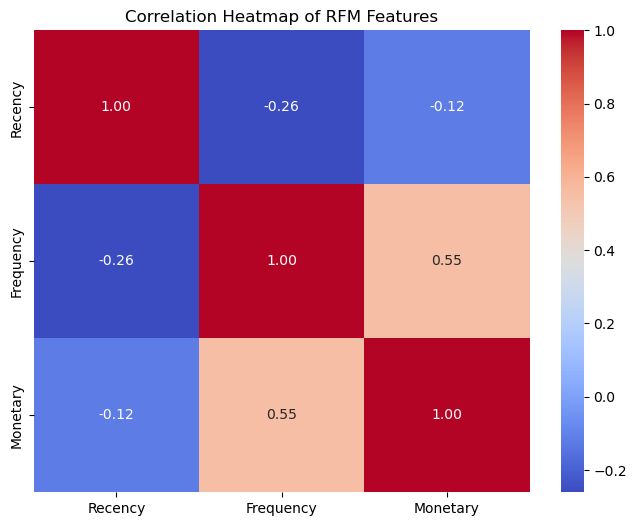

In [190]:
# Correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    rfm_df[['Recency','Frequency','Monetary']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of RFM Features")
plt.show()

**10. Feature Scaling:**

Before applying clustering algorithms like K-Means, we must scale our data. Because Monetary values are in the thousands. Frequency values are small integers.

K-Means uses distance-based calculations (Euclidean distance).

We use StandardScaler to transform the data so that each feature has a mean of 0 and a standard deviation of 1. This ensures all attributes contribute equally to the final clusters.

In [191]:
# Selecting the features
rfm_data = rfm_df[['Recency', 'Frequency', 'Monetary']]
# Initializing the Scaler
scaler = StandardScaler()
# Fitting and Transforming
rfm_scaled= scaler.fit_transform(rfm_data)
# Rebuilding the DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled , columns=rfm_data.columns, index=rfm_data.index)
rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


Scaling allows us to create same scale for all the attributes . Making it easier to calculate

**11. Finding optimal clusters(Elbow Method):**

We used the Elbow Method to find the ideal value for k.

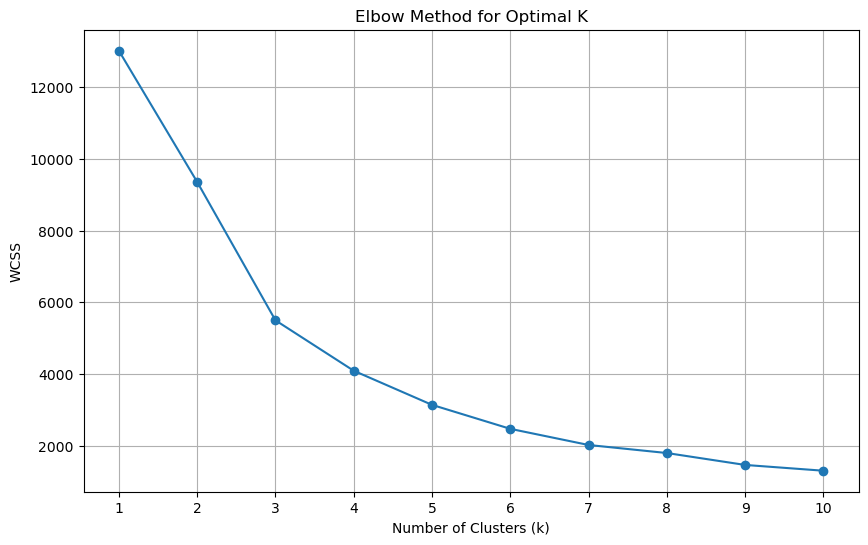

In [192]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)
# Plot elbow graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

Looking at the plot, the 'elbow' appears at k=3 or k=4. 
At this point, the decrease in WCSS (inertia) slows down significantly. 
Choosing this number allows us to capture the most distinct customer behaviors without over-complicating the segmentation.

What is WCSS?
WCSS stands for Within-Cluster Sum of Squares. WCSS as a clutter score. It measures the distance between each customer and the center of their group.
If the WCSS is high, the groups are big and messy.
If the WCSS is low, the groups are tight and the customers inside are very similar.

For Loop for k in range(1, 11):
Trying 10 different scenarios.

kmeans.inertia: This is actual WCSS value for that specific number of groups.

Finding the Elbow
plt.plot(range(1, 11), wcss, marker='o')

Look for the point where the line stops dropping sharply and starts leveling off.

**12. K-Means clustering :**

We have finalized the model with k=4. Each customer is now assigned to a cluster that represents their buying profile.

In [193]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
kmeans.fit(rfm_scaled_df)
rfm_df['Cluster'] = kmeans.labels_
print(rfm_df.head())

            Recency  Frequency  Monetary R_score F_score M_score RFM_segment  \
CustomerID                                                                     
12346.0         326          1  77183.60       1       1       5         115   
12347.0           2          7   4310.00       5       4       5         545   
12348.0          75          4   1797.24       2       3       4         234   
12349.0          19          1   1757.55       4       1       4         414   
12350.0         310          1    334.40       1       1       2         112   

            Cluster  
CustomerID           
12346.0           3  
12347.0           0  
12348.0           0  
12349.0           0  
12350.0           1  


Cluster | Potential Persona | Behavior |
| :--- | :--- | :--- |
| **Cluster 0** | Champions | High spenders, very frequent, shopped recently. |
| **Cluster 1** | At Risk | Haven't shopped in a long time, low frequency. |
| **Cluster 2** | Loyalists | Regular shoppers with medium spending. |
| **Cluster 3** | New/Recent | Shopped very recently but haven't spent much yet. |

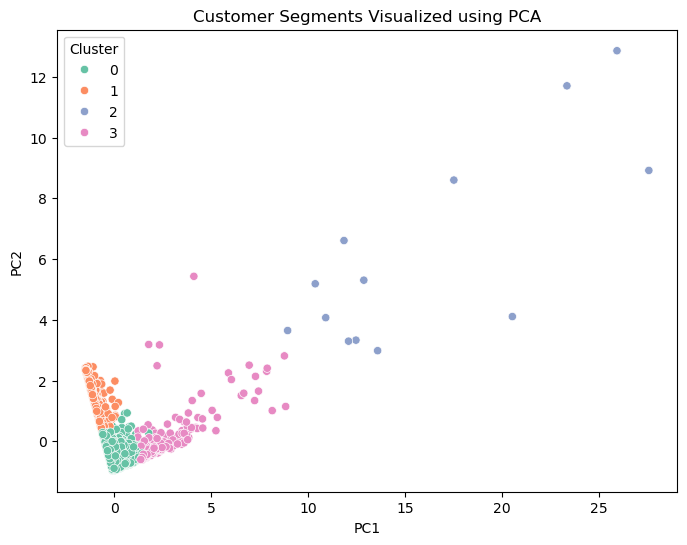

In [194]:
#PCA cluster visualization
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

# Convert to dataframe
pca_df = pd.DataFrame(rfm_pca, columns=['PC1','PC2'])
pca_df['Cluster'] = rfm_df['Cluster'].values

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set2'
)

plt.title("Customer Segments Visualized using PCA")
plt.show()

In [195]:
#Cluster personas
cluster_summary = rfm_df.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean',
    'Cluster':'count'
}).rename(columns={'Cluster':'Customer_Count'})

cluster_summary

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,43.702685,3.682711,1359.049284,3054
1,248.075914,1.552015,480.617480,1067
2,7.384615,82.538462,127338.313846,13
3,15.500000,22.333333,12709.090490,204


**13. Cluster Analysis:**

After analyzing the above graphs, we can define the four clusters:

Cluster 0  (Moderately engaged): Medium Recency and Frequency. They are steady customers but don't spend as much as VIPs.

Cluster 1 (At Risk/Churn): High Recency, Low Frequency, Low Monetary. These customers haven't visited in a long time and spent very little.

Cluster 2 (High Value):Low Recency, High Frequency, High Monetary. These are our VIP customers.

Cluster 3 (Promising): Very Low Recency but Low Frequency. These are new customers who just started shopping; we should welcome them!

Average RFM values per cluster:
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1359.05
1         248.08       1.55     480.62
2           7.38      82.54  127338.31
3          15.50      22.33   12709.09


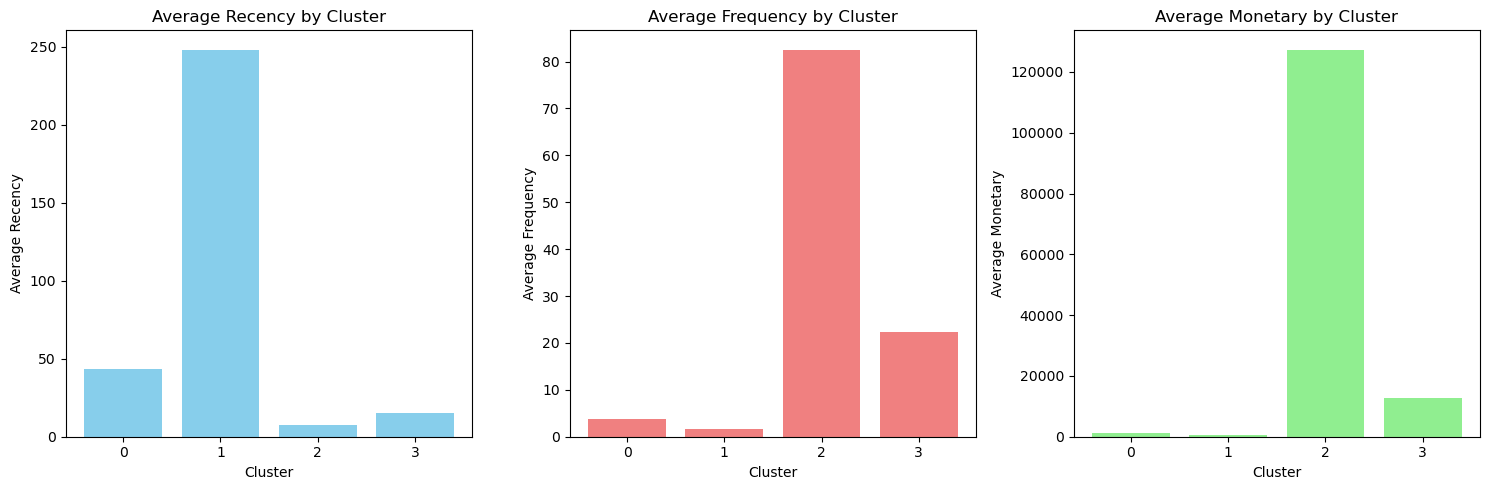

In [196]:
# This helps understand the behavioral characteristics of each customer segment.
cluster_analysis = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)
print("Average RFM values per cluster:")
print(cluster_analysis)
# Cluster Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(cluster_analysis.index, cluster_analysis['Recency'], color='skyblue')
plt.title('Average Recency by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Recency')
plt.xticks(cluster_analysis.index)

plt.subplot(1, 3, 2)
plt.bar(cluster_analysis.index, cluster_analysis['Frequency'], color='lightcoral')
plt.title('Average Frequency by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Frequency')
plt.xticks(cluster_analysis.index)

plt.subplot(1, 3, 3)
plt.bar(cluster_analysis.index, cluster_analysis['Monetary'], color='lightgreen')
plt.title('Average Monetary by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Monetary')
plt.xticks(cluster_analysis.index)

plt.tight_layout()
plt.show()

In [197]:
#Segment Revenue contribution
segment_revenue = rfm_df.groupby('Cluster')['Monetary'].sum().reset_index()
segment_revenue.columns = ['Cluster', 'Total_Monetary']
# Percentage Segment Revenue contribution
total_overall_monetary = rfm_df['Monetary'].sum()
segment_revenue['Percentage_Contribution'] = (segment_revenue['Total_Monetary'] / total_overall_monetary) * 100

segment_revenue

,Cluster,Total_Monetary,Percentage_Contribution
0,0,4150536.513,46.575542
1,1,512818.851,5.754633
2,2,1655398.080,18.576168
3,3,2592654.460,29.093657


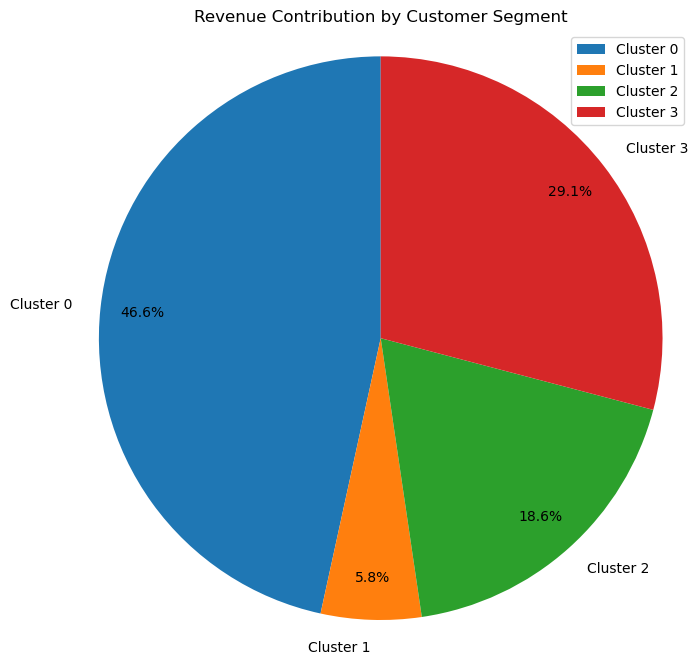

In [198]:
#Revenue contribution by  customer segment
plt.figure(figsize=(8, 8))
plt.pie(segment_revenue['Percentage_Contribution'], 
        labels=[f'Cluster {c}' for c in segment_revenue['Cluster']], 
        autopct='%1.1f%%', 
        startangle=90,
        pctdistance=0.85)
plt.title('Revenue Contribution by Customer Segment')
plt.legend(segment_revenue['Cluster'].apply(lambda x: f'Cluster {x}'), loc='best')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

The revenue contribution analysis shows that a small group of customers contributes a large portion of total revenue. These high-value customers represent an important segment that businesses should prioritize through loyalty programs and personalized marketing.
Lower-value segments generate smaller revenue but still represent opportunities for growth through targeted promotions and cross-selling strategies.

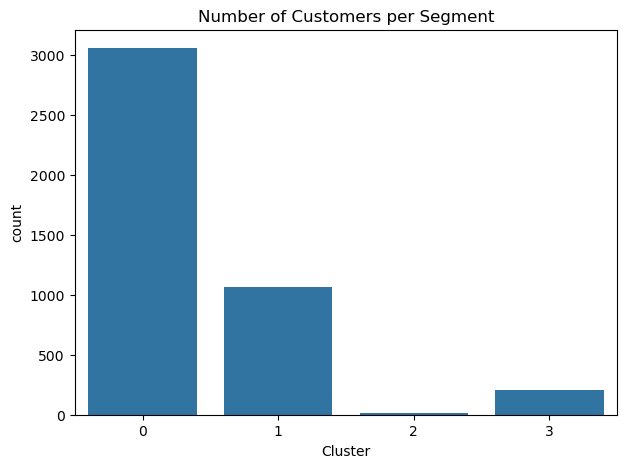

In [199]:
#Customer count per segment
plt.figure(figsize=(7,5))
sns.countplot(x='Cluster', data=rfm_df)
plt.title("Number of Customers per Segment")
plt.show()

**14. Business Recommendations:**

**Marketing Strategy Recommendations by Customer Segment:**

Based on the RFM analysis and revenue contribution, here are tailored marketing strategies for each identified customer segment:

***Cluster 0: Moderately Engaged*** (Average Recency: 43.70 days, Avg Frequency: 3.68, Avg Monetary: 1,359.05; Contributes 46.58% of Revenue)
    
1. Characteristics: This is the largest segment by revenue contribution and represents a solid base of customers who purchase regularly and spend a moderate amount. They are engaged but not top-tier.
    
2. Strategy: Focus on increasing purchase frequency and average order value. Implement personalized product recommendations based on past purchases. Offer loyalty program incentives for reaching higher spending tiers. Send targeted promotions for complementary products or services.Use email marketing to showcase new arrivals and limited-time offers to encourage repeat visits.
    
3. Goal: Move them towards higher frequency and monetary value, eventually transitioning them to the 'Promising' or 'High value' segments.

***Cluster-1: At-Risk/Churned*** (Average Recency: 248.08 days, Avg Frequency: 1.55, Avg Monetary: 480.62; Contributes 5.75% of Revenue)

1. Characteristics: These customers have not made a purchase recently, have low transaction frequency, and lower overall spending. They are at risk of churning or have already churned.

2. Strategy: Implement re-engagement and win-back campaigns. Send personalized offers with strong incentives to bring them back. Use surveys to understand reasons for inactivity and gather feedback. Consider retargeting ads on social media or search engines. Highlight new products or features that might appeal to their past interests

3. Goal: Reactivate these customers and prevent further churn, ideally moving them back to the 'Moderately Engaged' segment.

***Cluster 2: High-Value*** (Average Recency: 7.38 days, Avg Frequency: 82.54, Avg Monetary: 127,338.31; Contributes 18.58% of Revenue)

1. Characteristics: These are the most valuable customers, with recent, frequent, and high-value purchases. They are highly loyal and spend significantly.

2. Strategy: Prioritize retention and reward programs. Offer exclusive access to new products, VIP customer service, or special loyalty discounts.     Encourage referrals through exclusive ambassador programs. Solicit testimonials and reviews. Engage them with personalized content and appreciation events. Focus on building an even stronger emotional connection to the brand.

3. Goal: Maintain their loyalty, maximize their lifetime value, and leverage them as brand advocates.

***Cluster 3: Promising*** (Average Recency: 15.50 days, Avg Frequency: 22.33, Avg Monetary: $12,709.09; Contributes 29.09% of Revenue)

1. Characteristics: These customers are highly engaged, purchase frequently, and have substantial monetary value, though not as high as the 'High Value'. They are very loyal and valuable.

2. Strategy: Nurture their loyalty and encourage increased spending. Offer early access to sales or new collections. Provide personalized recommendations to cross-sell and up-sell. Run exclusive promotions for this segment. Encourage subscriptions or recurring purchases where applicable. Focus on personalized communication that recognizes their loyalty.

3. Goal: Elevate these customers to the 'High Value' segment by consistently providing value and encouraging higher engagement and spending.



**Summary:**

**Data Analysis Key Findings**

***Revenue Contribution by Segment:***

1. Cluster 0 (Moderately Engaged): Contributed the highest share of revenue at 46.58%, with a total monetary value of 4,150,536.51.
                        These customers generally have average recency (43.70 days), frequency (3.68), and monetary value (1,359.05).
                        
2. Cluster 1 (At-Risk/Churned): The lowest contributor, with only 5.75% of total revenue (512,818.85). 
                        These customers are characterized by poor recency (248.08 days), low frequency (1.55), and low monetary value (480.62).
                        
3. Cluster 2 (High-Value):Contributed 18.58% of total revenue (1,655,398.08). 
                        This segment comprises the most valuable customers with excellent recency (7.38 days), very high frequency (82.54), and                                exceptionally high monetary value (127,338.31).
                        
4. Cluster 3 (Promising): The second-highest contributor, accounting for 29.09% of total revenue, with a monetary value of 2,592,654.46. 
                       This segment exhibits good recency (15.50 days), high frequency (22.33), and substantial monetary value (12,709.09).



**Customer Segment Profiles:**

1. Cluster 0 (Moderately Engaged): Represents a significant portion of revenue, indicating a solid customer base that needs nurturing to increase                                         engagement.

2. Cluster 1 (At-Risk/Churned): Consists of inactive or nearly inactive customers, posing a risk of complete churn.

3. Cluster 2 (High-Value): The most valuable and loyal customers, critical for sustained business growth.

4. Cluster 3 (Promising): Highly engaged customers with strong potential to become 'Champions' with targeted strategies.



**Insights :**

1. The business should prioritize retaining and rewarding 'High Value' (Cluster 2) and 'Promising' customers (Cluster 3), given their high 
       engagement and significant revenue contributions, while strategically nurturing 'Moderately Engaged' customers (Cluster 0) to elevate 
       their value.
2. Focused re-engagement campaigns are crucial for 'At-Risk/Churned' customers (Cluster 1) to prevent further loss of potentialrevenue 
       and understand underlying reasons for inactivity.

In [200]:
cleaned_data = clean_online_retail.to_csv('online  retail filtered.csv')